Selected topic for mini-project: \
**Embedding-Based Classifier.**

In [1]:
import re
from typing import List, Callable, Any, Dict
from datasets import load_dataset
from functorch.dim import softmax
from gensim.models import Word2Vec, KeyedVectors
from sklearn.metrics import f1_score
import gensim.downloader as api
import torch
import copy
import random
import numpy as np
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

/Users/kirillgorunov/miniconda3/envs/nlp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Download dataset **ag_news**:

In [2]:
dataset = load_dataset("ag_news")

Select train & text:

In [3]:
train_text = dataset["train"]
test_text = dataset["test"]

Sample example:

we have text with new's title and description, and one of four labels

In [ ]:
train_text[634]

Tokenize all train text:

In [5]:
def tokenize(text: str, pattern: str = None) -> List[str]:
    pattern = r"(?:\w+')\w+|(?:[A-Z]\.)+|\w+(?:-\w+)*|[\w+\.]"
    tokens = re.findall(pattern, text)
    return tokens

Tokenize train and test tokens

In [6]:
train_tokens = [tokenize(text_sample) for text_sample in list(train_text["text"])]
test_tokens = [tokenize(text_sample) for text_sample in list(test_text["text"])]

And get all tokens for training

In [7]:
all_tokens = train_tokens + test_tokens

In [8]:
VOCAB_SIZE = len(all_tokens)

First, we will train our model on **all corpus of text**:

Create Word2Vec model

In [9]:
model_w2v_locally_train_all_dataset = Word2Vec(
    vector_size=300,
    window=4,
    min_count=1,
    sg=1,
    epochs=2000,
    seed=42,
    workers=12,
    negative=6,
)
model_w2v_locally_train_all_dataset.build_vocab(all_tokens)

Train our Word2Vec model:

In [10]:
model_w2v_locally_train_all_dataset.train(
    corpus_iterable=all_tokens,
    total_examples=len(all_tokens),
    epochs=1,
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


(4249301, 5154488)

Also, we train word2vec on small data (30% of dataset)

In [11]:
percent_30_dataset = random.sample(all_tokens, int(len(all_tokens) * 0.30))

In [12]:
model_w2v_locally_train_30_percent = Word2Vec(
    vector_size=300,
    window=4,
    min_count=1,
    sg=1,
    epochs=2000,
    seed=42,
    workers=12,
    negative=6,
)
model_w2v_locally_train_30_percent.build_vocab(percent_30_dataset)
model_w2v_locally_train_30_percent.train(
    corpus_iterable=percent_30_dataset,
    total_examples=len(percent_30_dataset),
    epochs=1,
)

(38, 160)

And last model is pretrained word2vec

In [13]:
# path = api.load("word2vec-google-news-300", return_path=True)
# print('download to:', path)
path = "/Users/kirillgorunov/gensim-data/word2vec-google-news-300"

In [14]:
# !gzip -d path

In [15]:
google_w2v_model_pretrained = KeyedVectors.load_word2vec_format(f'{path}/word2vec-google-news-300', binary=True)

Now we have all 3 type of word2vec models and next part is prepare dataset

We know that existing 2 types of create "embedding" of sentence from words embedding - pooling and concatenation

In this word we will use pooling

In [30]:
def get_if_in(w2v_model, token, embedding_dim=300):
    if hasattr(w2v_model, "wv"):
        if token in w2v_model.wv:
            return w2v_model.wv[token]
        else:
            return np.zeros(embedding_dim)
    else:
        if token in w2v_model:
            return w2v_model[token]
        else:
            return np.zeros(embedding_dim)


def pool_sentence(sentense_raw: str, w2v_model, embedding_dim=300) -> np.ndarray[Any]:
    sentense_tokens: List[str] = tokenize(sentense_raw)
    sentense = [get_if_in(w2v_model=w2v_model, token=token, embedding_dim=embedding_dim) for token in sentense_tokens]
    # pool
    if not sentense:
        return np.zeros(embedding_dim)
    result = np.array(sentense).mean(axis=0)
    return result

Example of our function:

Sentence -> tokenize each word -> take mean of all vectors

In [17]:
pool_sentence(train_text["text"][0], w2v_model=google_w2v_model_pretrained)

array([ 4.53836192e-02,  4.94650136e-02, -4.36268682e-02,  5.49528702e-02,
       -8.33262568e-04, -3.70974333e-02, -3.31447435e-02, -9.63877802e-02,
        6.93518597e-02, -3.17382812e-03, -3.76693062e-02, -6.78020975e-04,
        2.91596703e-02,  1.98563285e-02, -8.43983526e-02, -1.11285666e-01,
        3.45266591e-02,  2.69987687e-02, -4.19852215e-02, -2.53216287e-02,
       -9.69132133e-03,  4.18648098e-02,  3.60983144e-02,  1.91394972e-02,
        4.79470958e-02,  4.28735484e-02, -9.23063859e-02,  7.39149011e-02,
        6.46514893e-02, -1.43299932e-04,  7.41975204e-03,  7.16552734e-02,
       -3.82770041e-02, -1.10261337e-03, -2.49806280e-02, -4.34119183e-02,
        7.93058976e-02,  7.03058657e-02, -1.02718187e-02,  3.67697011e-02,
        4.38895847e-02, -1.31549338e-01,  1.33003567e-02, -4.24327021e-02,
       -5.74327552e-03, -1.52793553e-02, -3.80686884e-02, -5.04641326e-02,
        1.83609672e-02,  4.14083730e-02, -6.56960529e-02,  6.31395423e-02,
       -3.79966653e-02, -

And prepare data:

In [18]:
# full
X_locally_full_ag_news = torch.tensor([pool_sentence(sample, model_w2v_locally_train_all_dataset) for sample in train_text["text"]], dtype=torch.float32)
y_locally_full_ag_news = torch.tensor(train_text["label"], dtype=torch.long)

/var/folders/y5/f3lzxvn542d8prr4rnvmc1dw0000gn/T/ipykernel_71169/3436350375.py:2: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  X_locally_full_ag_news = torch.tensor([pool_sentence(sample, model_w2v_locally_train_all_dataset) for sample in train_text["text"]], dtype=torch.float32)


In [33]:
X_test_locally_full_ag_news = torch.tensor([pool_sentence(sample, model_w2v_locally_train_all_dataset) for sample in test_text["text"]], dtype=torch.float32)
y_test_locally_full_ag_news = torch.tensor(test_text["label"], dtype=torch.long)

In [20]:
X_train_locally_full_ag_news, X_val_locally_full_ag_news, y_train_locally_full_ag_news, y_val_locally_full_ag_news = train_test_split(X_locally_full_ag_news, y_locally_full_ag_news, test_size=0.2, random_state=42)

---------------------

In [32]:
# 30 % dataset
X_locally_30_ag_news = torch.tensor([pool_sentence(sample, model_w2v_locally_train_30_percent) for sample in train_text["text"]], dtype=torch.float32)
y_locally_30_ag_news = torch.tensor(train_text["label"], dtype=torch.long)

KeyboardInterrupt: 

In [ ]:
X_test_locally_30_ag_news = torch.tensor([pool_sentence(sample, model_w2v_locally_train_30_percent) for sample in test_text["text"]], dtype=torch.float32)
y_test_locally_30_ag_news = torch.tensor(test_text["label"], dtype=torch.long)

In [ ]:
X_train_locally_30_ag_news, X_val_locally_30_ag_news, y_train_locally_30_ag_news, y_val_locally_30_ag_news = train_test_split(X_locally_30_ag_news, y_locally_30_ag_news, test_size=0.2, random_state=42)

-------------------

In [ ]:
# pretrained
X_pretrained_ag_news = torch.tensor([pool_sentence(sample, google_w2v_model_pretrained) for sample in train_text["text"]], dtype=torch.float32)
y_pretrained_ag_news = torch.tensor(train_text["label"], dtype=torch.long)

In [ ]:
X_test_pretrained_ag_news = torch.tensor([pool_sentence(sample, google_w2v_model_pretrained) for sample in test_text ["text"]], dtype=torch.float32)
y_test_pretrained_ag_news = torch.tensor(test_text["label"], dtype=torch.long)

In [ ]:
X_train_pretrained_ag_news, X_val_pretrained_ag_news, y_train_pretrained_ag_news, y_val_pretrained_ag_news = train_test_split(X_pretrained_ag_news, y_pretrained_ag_news, test_size=0.2, random_state=42)

Define our nn model:

2 hidden layes

relu activation

In [191]:
class FNNModel(torch.nn.Module):
    def __init__(self, embedding_dim=300, hidden_dim_1=400, hidden_dim_2=100, num_classes=4):
        super().__init__()

        self.fc1 = torch.nn.Linear(embedding_dim, hidden_dim_1)
        self.fc2 = torch.nn.Linear(hidden_dim_1, hidden_dim_2)
        self.output = torch.nn.Linear(hidden_dim_2, num_classes)
        self.relu = torch.nn.ReLU()

    def forward(self, input):
        o1 = self.relu(self.fc1(input))
        o2 = self.relu(self.fc2(o1))
        result = self.output(o2)
        return result


Create train and metric functions:

We will use mini-batch learning with early stopping

In [17]:
def accuracy(y_pred, y):
    # multiclasses
    classes = y_pred.argmax(dim=1)
    return (classes == y).float().mean()

def train(model_nn: torch.nn.Module,
          loss: Callable,
          opt: Callable,
          X_train: torch.Tensor,
          y_train: torch.Tensor,
          X_valid: torch.Tensor,
          y_valid: torch.Tensor,
          lr: float,
          batch_size: int,
          epochs: int):

    loss_history: List[float] = list()
    batch_count = int(len(X_train) / batch_size)
    best_res_accuracy = -1.0
    best_weights = None

    optimizer = opt(model_nn.parameters(), lr=lr)

    count_accuracy_same = 0
    max_count_accuracy_same = 30

    for epoch in range(epochs):
        model_nn.train()
        for batch_num in range(batch_count):
            batch_start = batch_num * batch_size

            X_train_batch = X_train[batch_start:batch_start + batch_size]
            y_train_batch = y_train[batch_start:batch_start + batch_size]

            y_pred = model_nn(X_train_batch)
            loss_res = loss(y_pred, y_train_batch)

            optimizer.zero_grad()
            loss_res.backward()

            optimizer.step()

            loss_history.append(float(loss_res))

        model_nn.eval()
        y_pred = model_nn(X_valid)

        new_accuracy = accuracy(y_pred, y_valid)
        print(f"Epoch {epoch + 1}/{epochs}, loss: {float(loss_res)}, accuracy: {float(new_accuracy)}")
        if new_accuracy > best_res_accuracy:
            best_res_accuracy = new_accuracy
            best_weights = copy.deepcopy(model_nn.state_dict())
            count_accuracy_same = 0
        else:
            count_accuracy_same += 1

        if max_count_accuracy_same == count_accuracy_same:
            print(f"early stopped on epoch: {epoch}. best accuracy: {best_res_accuracy}")
            break

    print(f"Total epoch: {epoch}. best accuracy: {best_res_accuracy}")
    model_nn.load_state_dict(best_weights)

    return loss_history, best_res_accuracy

Train our models:

In [18]:
nn_model_locally_full_dataset = FNNModel()

loss_history, best_accuracy = train(
    model_nn=nn_model_locally_full_dataset,
    loss=torch.nn.CrossEntropyLoss(),
    opt=torch.optim.Adam,
    X_train=X_train_locally_full_ag_news,
    y_train=y_train_locally_full_ag_news,
    X_valid=X_val_locally_full_ag_news,
    y_valid=y_val_locally_full_ag_news,
    lr=0.1,
    batch_size=64,
    epochs=100,
)

print(f'nn_model_locally_full_dataset. Accuracy on valid: {nn_model_locally_full_dataset.accuracy:.4f}')

/var/folders/y5/f3lzxvn542d8prr4rnvmc1dw0000gn/T/ipykernel_54671/3694026848.py:43: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  loss_history.append(float(loss_res))


Epoch 1/100, loss: 0.2455771565437317, accuracy: 0.8852916955947876
Epoch 2/100, loss: 0.4050082564353943, accuracy: 0.8809999823570251
Epoch 3/100, loss: 0.30374836921691895, accuracy: 0.8799583315849304
Epoch 4/100, loss: 0.30900636315345764, accuracy: 0.8798333406448364
Epoch 5/100, loss: 0.28521475195884705, accuracy: 0.8865416646003723
Epoch 6/100, loss: 0.3155996799468994, accuracy: 0.8706666827201843
Epoch 7/100, loss: 0.32029467821121216, accuracy: 0.8723333477973938
Epoch 8/100, loss: 0.2925831973552704, accuracy: 0.8855416774749756
Epoch 9/100, loss: 0.30466094613075256, accuracy: 0.8796250224113464
Epoch 10/100, loss: 0.2637571096420288, accuracy: 0.890291690826416
Epoch 11/100, loss: 0.29938453435897827, accuracy: 0.8809999823570251
Epoch 12/100, loss: 0.29327595233917236, accuracy: 0.8799583315849304
Epoch 13/100, loss: 0.27409976720809937, accuracy: 0.890250027179718
Epoch 14/100, loss: 0.27750906348228455, accuracy: 0.8806666731834412
Epoch 15/100, loss: 0.35263651609420

In [ ]:
plt.plot(loss_history[4:-1:300])
plt.title('Loss history for nn_model_locally_full_dataset')
plt.xlabel('Epoch')
plt.ylabel('Loss')

In [ ]:
nn_model_locally_30_dataset = FNNModel()

loss_history, best_accuracy = train(
    model_nn=nn_model_locally_30_dataset,
    loss=torch.nn.CrossEntropyLoss(),
    opt=torch.optim.Adam,
    X_train=X_train_locally_30_ag_news,
    y_train=y_train_locally_30_ag_news,
    X_valid=X_val_locally_30_ag_news,
    y_valid=y_val_locally_30_ag_news,
    lr=0.1,
    batch_size=64,
    epochs=100,
)

print(f'nn_model_locally_30_dataset. Accuracy on valid: {best_accuracy:.4f}')

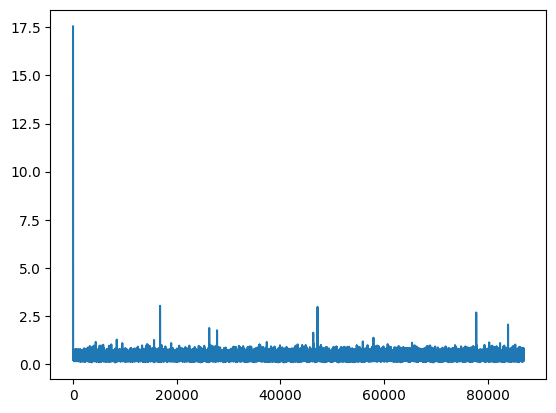

In [19]:
plt.plot(loss_history[4:-1:300])
plt.title('Loss history for nn_model_locally_30_dataset')
plt.xlabel('Epoch')
plt.ylabel('Loss')

In [ ]:
nn_model_pretrained = FNNModel()

loss_history, best_accuracy = train(
    model_nn=nn_model_pretrained,
    loss=torch.nn.CrossEntropyLoss(),
    opt=torch.optim.Adam,
    X_train=X_train_pretrained_ag_news,
    y_train=y_train_pretrained_ag_news,
    X_valid=X_val_pretrained_ag_news,
    y_valid=y_val_pretrained_ag_news,
    lr=0.1,
    batch_size=64,
    epochs=100,
)

print(f'nn_model_locally_30_dataset. Accuracy on valid: {best_accuracy:.4f}')

In [ ]:
plt.plot(loss_history[4:-1:300])
plt.title('Loss history for nn_model_locally_30_dataset')
plt.xlabel('Epoch')
plt.ylabel('Loss')

Now we can calculate f1-score and accuracy on test dataset

In [24]:
models = [
    (nn_model_locally_full_dataset, X_test_locally_full_ag_news, y_test_locally_full_ag_news),
    (nn_model_locally_30_dataset, X_test_locally_30_ag_news, y_test_locally_30_ag_news),
    (nn_model_pretrained, X_test_pretrained_ag_news, y_test_pretrained_ag_news),
]
for model, x_test_d, y_test_d in models:
    model.eval()
    with torch.no_grad():
        y_pred = model(x_test_d)
        print(f'accuracy for {model.__name__}:', accuracy(y_pred, y_test_d))
        classes = y_pred.argmax(dim=1)
        f1 = f1_score(y_true=y_test_d, y_pred=classes, average=None)
        print(f'f1 score  for {model.__name__}:', f1)

tensor([[0.0200, 0.9600, 0.0100, 0.0100]])


Last model for our task - without "pretrained" embedding

we will use torch.nn.Embedding with random init to train our embedding with backprop

In [165]:
class FNNWithEmbedding(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = torch.nn.Embedding(num_embeddings=VOCAB_SIZE, embedding_dim=300)
        self.fc1 = torch.nn.Linear(300, 400)
        self.fc2 = torch.nn.Linear(400, 100)
        self.output = torch.nn.Linear(100, 4)
        self.relu = torch.nn.ReLU()

    def forward(self, input):
        input_embedding = self.embedding(input)
        pooled = input_embedding.mean(dim=1)
        o1 = self.relu(self.fc1(pooled))
        o2 = self.relu(self.fc2(o1))
        result = self.output(o2)
        return result

We need to prepare input for model:

word -> number in vocab

sentences -> list of number in vocab

In [64]:
all_tokens_vector = [token for sentence in all_tokens for token in sentence]

In [65]:
vocab = {token: token_id for token_id, token in enumerate(set(all_tokens_vector))}
vocab["<UNK>"] = 0

In [66]:
def text_to_ids(text: str, vocab: Dict[str, int]):
    matrix_result = np.zeros(300)
    ids = [vocab.get(token, 0) for token in tokenize(text)]
    ids = ids[:300]
    matrix_result[:len(ids)] = ids
    return matrix_result

Example of sample sentence:

In [60]:
text_to_ids(train_text["text"][0], vocab)

array([100858.,  12634.,   9874.,  81694.,  24901.,  60769., 100537.,
         5423.,  62890.,  15990.,  15990.,  89418., 100858.,   1073.,
        30360.,  61094.,  31900.,  81409.,  85832.,  68435.,  19787.,
        53974.,   9874.,      0.,      0.,      0.,      0.,      0.,
            0.,      0.,      0.,      0.,      0.,      0.,      0.,
            0.,      0.,      0.,      0.,      0.,      0.,      0.,
            0.,      0.,      0.,      0.,      0.,      0.,      0.,
            0.,      0.,      0.,      0.,      0.,      0.,      0.,
            0.,      0.,      0.,      0.,      0.,      0.,      0.,
            0.,      0.,      0.,      0.,      0.,      0.,      0.,
            0.,      0.,      0.,      0.,      0.,      0.,      0.,
            0.,      0.,      0.,      0.,      0.,      0.,      0.,
            0.,      0.,      0.,      0.,      0.,      0.,      0.,
            0.,      0.,      0.,      0.,      0.,      0.,      0.,
            0.,     

In [47]:
X_embedding = torch.tensor([text_to_ids(sample, vocab) for sample in train_text["text"]], dtype=torch.long)
y_embedding = torch.tensor(train_text["label"], dtype=torch.long)

In [61]:
X_train_embedding, X_val_embedding, y_train_embedding, y_val_embedding = train_test_split(X_embedding, y_embedding, test_size=0.2, random_state=42)

In [119]:
nn_model_embedding = FNNWithEmbedding()

loss_history, best_accuracy = train(
    model_nn=nn_model_embedding,
    loss=torch.nn.CrossEntropyLoss(),
    opt=torch.optim.Adam,
    X_train=X_train_embedding,
    y_train=y_train_embedding,
    X_valid=X_val_embedding,
    y_valid=y_val_embedding,
    lr=0.001,
    batch_size=64,
    epochs=100,
)

Epoch 1/2, loss: 0.26229754090309143, accuracy: 0.875124990940094
Epoch 2/2, loss: 0.15814881026744843, accuracy: 0.8919583559036255
Total epoch: 1. best accuracy: 0.8919583559036255


In [ ]:
plt.plot(loss_history[4:-1:300])
plt.title('Loss history for nn_model_embedding')
plt.xlabel('Epoch')
plt.ylabel('Loss')

In [70]:
X_test_embeddings = torch.tensor(text_to_ids(train_text["text"][0], vocab), dtype=torch.long)
y_test_embeddings = torch.tensor(train_text["label"], dtype=torch.long)

In [ ]:
models = [
    (nn_model_embedding, X_test_embeddings, y_test_embeddings),
]
for model, x_test_d, y_test_d in models:
    model.eval()
    with torch.no_grad():
        y_pred = model(x_test_d)
        print(f'accuracy for {model.__name__}:', accuracy(y_pred, y_test_d))
        classes = y_pred.argmax(dim=1)
        f1 = f1_score(y_true=y_test_d, y_pred=classes, average=None)
        print(f'f1 score  for {model.__name__}:', f1)

In [120]:
for name, param in nn_model_embedding.named_parameters():
    if param.grad is not None:
        print(name, param.grad.norm().item())

embedding.weight 0.6926902532577515
fc1.weight 1.438224196434021
fc1.bias 0.2786840498447418
fc2.weight 0.1610797792673111
fc2.bias 0.07215234637260437
output.weight 0.2638908326625824
output.bias 0.05889728292822838
